# Unsupervised Feature Selection Using Sparse Manifold Auto-Encoder (SMFAE)

## Dataset: Colon Microarray ($d=2000$ features, $n=62$ samples, 2 classes)

**Paper Reference**: Moslemi, A., & Jamshidi, M. (2025). *Unsupervised feature selection using sparse manifold learning: Auto-encoder approach*. Information Processing and Management, 62(1), 103923.

### Module 1: Environment Setup & Library Imports

Import standard numerical, optimization, clustering, and preprocessing tools, and fix the random seed for reproducibility.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler

# Random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Module 1 initialized: Environment ready.")


Module 1 initialized: Environment ready.


## Module 2: Data Loading & Preprocessing

Load the Colon CSV dataset, separate feature columns from the class label, apply Z-score
standardization across samples, and transpose to the paper's matrix notation
$X \in \mathbb{R}^{d \times n}$ ($d=2000$ features, $n=62$ samples).

In [2]:
def load_and_preprocess_colon(csv_path="../data/preprocessed/colon.csv"):
    '''Loads the Colon CSV, applies Z-score normalization, and transposes to X in R^(d x n).'''
    df = pd.read_csv(csv_path)

    # Identify label column
    if "target" in df.columns:
        label_col = "target"
    elif "label" in df.columns:
        label_col = "label"
    else:
        label_col = df.columns[-1]

    y_true = df[label_col].to_numpy()
    X_df = df.drop(columns=[label_col])
    X_raw = X_df.to_numpy(dtype=np.float64)

    # 1. Z-score standardization across samples
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # 2. Transpose to paper notation: X in R^(d x n)
    X = X_scaled.T

    return X, y_true


# Execute loading
CSV_PATH = "../data/preprocessed/colon.csv"  # update path if needed
X, y_true = load_and_preprocess_colon(CSV_PATH)

d_features, n_samples = X.shape
n_classes = len(np.unique(y_true))

print(
    f"Colon Dataset Loaded: d = {d_features} features, n = {n_samples}"
    f" samples, classes = {n_classes}"
)
assert X.shape == (2000, 62), f"Expected X shape (2000, 62), but got {X.shape}"


Colon Dataset Loaded: d = 2000 features, n = 62 samples, classes = 2


## Module 3: Graph Laplacian Matrix ($L_X$) Construction

Build a $k$-nearest-neighbor ($k=5$) graph using Gaussian kernel similarity
$A_{ij} = \exp(-\|x_i - x_j\|^2 / 2\sigma^2)$. Compute the degree matrix $D$ and construct the
unnormalized Laplacian $L_X = D - A \in \mathbb{R}^{62 \times 62}$.

In [3]:
def build_graph_laplacian(X, k=5):
    '''Constructs symmetric k-NN similarity matrix A and Graph Laplacian L_X = D - A.'''
    d, n = X.shape
    X_samples = X.T  # (n, d)

    # Pairwise squared Euclidean distances
    dist_sq = cdist(X_samples, X_samples, metric="sqeuclidean")

    # Bandwidth sigma estimated from median distance
    nonzero_dist = dist_sq[dist_sq > 0]
    median_d = np.median(nonzero_dist) if len(nonzero_dist) > 0 else 1.0
    sigma = np.sqrt(median_d)

    # Symmetric k-NN adjacency matrix
    A = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        knn_indices = np.argsort(dist_sq[i])[1 : k + 1]
        for j in knn_indices:
            sim = np.exp(-dist_sq[i, j] / (2.0 * (sigma ** 2)))
            A[i, j] = sim
            A[j, i] = sim  # symmetrize

    np.fill_diagonal(A, 0.0)

    # Degree matrix D and Laplacian L_X = D - A
    D = np.diag(np.sum(A, axis=1))
    L_X = D - A
    return L_X, A, D


L_X, A_mat, D_mat = build_graph_laplacian(X, k=5)
print(f"Graph Laplacian L_X constructed: shape {L_X.shape}")
assert L_X.shape == (n_samples, n_samples)


Graph Laplacian L_X constructed: shape (62, 62)


## Module 4: Sparse Manifold Auto-Encoder Optimization Engine

Implement forward propagation with a Sigmoid encoder $Z = \sigma(W^{(1)T}X)$ and a **Linear**
decoder $\hat{X} = W^{(2)T}Z$ (chosen so the decoder can reproduce Z-scored real-valued data),
backpropagation gradients for $W^{(1)}$ and $W^{(2)}$, the $l_{2,1}$ sparsity matrix $Q$, the
multiplicative update for the auxiliary matrix $H$, and the master training loop
(`train_smfae`).

In [4]:
# Cell 4: Module 4 — SMFAE Optimization Engine (Corrected Gradients & H Update)

import numpy as np


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))


def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1.0 - s)


def compute_gradients(
    W1, W2, X, L_X, H,
    alpha=0.01,
    beta=0.0001,
    gamma=0.001,
    omega=0.001
):
    """Computes analytical gradients matching Moslemi & Jamshidi (2025) Eq. 8 & 9."""

    d, n = X.shape

    # Forward pass
    A_act = np.dot(W1.T, X)
    Z = sigmoid(A_act)
    X_hat = np.dot(W2.T, Z)

    # Backpropagation
    delta_o = X_hat - X
    delta_h = np.dot(W2, delta_o) * sigmoid_deriv(A_act)

    # 1. Reconstruction gradients
    grad_W1_recon = np.dot(X, delta_h.T) / n
    grad_W2_recon = (np.dot(delta_o, Z.T) / n).T

    # 2. L2,1 sparsity regularization
    eps = 1e-8
    row_norms = np.sqrt(np.sum(W1**2, axis=1) + eps)
    Q = np.diag(1.0 / row_norms)

    grad_W1_sparse = alpha * np.dot(Q, W1)

    # 3. Weight decay
    grad_W1_decay = beta * W1
    grad_W2_decay = beta * W2

    # 4. Input manifold regularization
    grad_W1_input = (
        gamma
        * np.dot(np.dot(np.dot(X, L_X), X.T), W1)
    )
    
    # 5. Output manifold regularization
    HH_T = np.dot(H, H.T)
    
    grad_W2_output = (
        omega
        * np.dot(np.dot(np.dot(Z, HH_T), Z.T), W2)
    )
    
    grad_Z_output = (
        omega
        * np.dot(np.dot(np.dot(W2, W2.T), Z), HH_T)
    )
    
    delta_Z_output = grad_Z_output * sigmoid_deriv(A_act)
    
    grad_W1_output = np.dot(X, delta_Z_output.T)

    # Total gradients
    grad_W1 = (
        grad_W1_recon
        + grad_W1_sparse
        + grad_W1_decay
        + grad_W1_input
        + grad_W1_output
    )

    grad_W2 = (
        grad_W2_recon
        + grad_W2_decay
        + grad_W2_output
    )

    return grad_W1, grad_W2


def update_auxiliary_H(H, A_mat, D_mat, eps=1e-8):
    """Multiplicative update for H >= 0 using positive/negative gradient splitting."""

    num = 2.0 * np.dot(A_mat, H)

    den = (
        2.0 * np.dot(D_mat, H)
        + 4.0 * np.dot(np.dot(H, H.T), H)
        + eps
    )

    H_updated = H * (num / den)

    return np.maximum(H_updated, eps)


def train_smfae(
    X,
    L_X,
    A_mat,
    D_mat,
    hidden_dim=4,
    alpha=0.01,
    beta=0.0001,
    gamma=0.001,
    omega=0.001,
    epochs=250,
    rho1=5e-3,
    rho2=2e-3,
    seed=42,
):
    """Master training engine for Sparse Manifold Auto-Encoder."""

    d, n = X.shape
    k = hidden_dim

    rng = np.random.default_rng(seed)

    # Initialization
    limit_W1 = np.sqrt(6.0 / (d + k))
    limit_W2 = np.sqrt(6.0 / (k + d))

    W1 = rng.uniform(
        -limit_W1,
        limit_W1,
        size=(d, k)
    )

    W2 = rng.uniform(
        -limit_W2,
        limit_W2,
        size=(k, d)
    )

    H = (
        np.abs(
            rng.normal(
                0.0,
                0.01,
                size=(n, n)
            )
        )
        + 1e-3
    )

    for epoch in range(1, epochs + 1):

        grad_W1, grad_W2 = compute_gradients(
            W1,
            W2,
            X,
            L_X,
            H,
            alpha,
            beta,
            gamma,
            omega
        )

        # Gradient descent
        W1 -= rho1 * grad_W1
        W2 -= rho2 * grad_W2

        # Multiplicative H update
        H = update_auxiliary_H(
            H,
            A_mat,
            D_mat
        )

        # Numerical safety
        W1 = np.nan_to_num(
            W1,
            nan=0.0,
            posinf=1e6,
            neginf=-1e6
        )

        W2 = np.nan_to_num(
            W2,
            nan=0.0,
            posinf=1e6,
            neginf=-1e6
        )

    return W1, W2, H


print("Module 4 compiled: Optimization engine ready.")

Module 4 compiled: Optimization engine ready.


## Module 5: Model Training & Feature Importance Ranking

Train the auto-encoder on the Colon dataset with hidden layer size
$k = \operatorname{round}(\sqrt{62}/2) = 4$. Compute feature importance scores
$s_i = \|w_i^{(1)}\|_2$ from the encoder weight matrix $W^{(1)}$ and rank features in
descending order.

In [5]:
# Cell 5: Module 5 — Training Execution & Hyperparameter Tuning Helper

HIDDEN_DIM = int(np.round(np.sqrt(n_samples) / 2.0))  # k = 4 for Colon (n=62)


def train_and_rank(
    X,
    L_X,
    A_mat,
    D_mat,
    alpha_val,
    gamma_val,
    omega_val,
    rho1_val,
    epochs=250
):
    """Train SMFAE for a specific hyperparameter combination."""

    W1, W2, H = train_smfae(
        X=X,
        L_X=L_X,
        A_mat=A_mat,
        D_mat=D_mat,
        hidden_dim=HIDDEN_DIM,
        alpha=alpha_val,
        beta=0.0001,
        gamma=gamma_val,
        omega=omega_val,
        epochs=epochs,
        rho1=rho1_val,
        rho2=2e-3,
        seed=RANDOM_SEED
    )

    feature_scores = np.linalg.norm(W1, axis=1)
    ranked_indices = np.argsort(feature_scores)[::-1]

    return ranked_indices


print("Cell 5 ready: Joint hyperparameter grid-search helper defined.")

Cell 5 ready: Joint hyperparameter grid-search helper defined.


## Module 6: Benchmark Evaluation (ACC & NMI)

Evaluate selected feature subsets $r \in \{50, 100, 150, 200, 250, 300\}$. For each subset,
standardize the features with `StandardScaler` and evaluate K-Means ($K=2$, 30 repetitions)
using Clustering Accuracy (ACC, via the Hungarian algorithm) and Normalized Mutual Information
(NMI).

In [7]:
# Cell 6: Module 6 — Joint Grid Search over Alpha, Gamma, Omega and Rho1

import itertools

from scipy.optimize import linear_sum_assignment


def calculate_acc(y_true, y_pred):
    """Computes Clustering Accuracy (ACC) using Hungarian algorithm."""

    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)

    _, y_true = np.unique(y_true, return_inverse=True)
    _, y_pred = np.unique(y_pred, return_inverse=True)

    D = max(y_pred.max(), y_true.max()) + 1

    w = np.zeros((D, D), dtype=np.int64)

    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1

    row_ind, col_ind = linear_sum_assignment(w.max() - w)

    return w[row_ind, col_ind].sum() / y_pred.size

feature_counts = [100]

alpha_candidates = [0.1, 1.0, 10.0]
gamma_candidates = [0.0001, 0.001, 0.01, 0.1]
omega_candidates = [0.0001, 0.001, 0.01, 0.1]
rho1_candidates = [0.005, 0.01, 0.02]

best_nmi = -1.0
best_alpha = None
best_gamma = None
best_omega = None
best_rho1 = None
best_results_df = None

grid_results = []

total_combinations = (
    len(alpha_candidates)
    * len(gamma_candidates)
    * len(omega_candidates)
    * len(rho1_candidates)
)

combination_number = 0

print("=== Running Joint Hyperparameter Grid Search ===")
print(f"Total combinations: {total_combinations}")
print()

for alpha_val, gamma_val, omega_val, rho1_val in itertools.product(
    alpha_candidates,
    gamma_candidates,
    omega_candidates,
    rho1_candidates
):

    combination_number += 1

    ranked_indices = train_and_rank(
        X=X,
        L_X=L_X,
        A_mat=A_mat,
        D_mat=D_mat,
        alpha_val=alpha_val,
        gamma_val=gamma_val,
        omega_val=omega_val,
        rho1_val=rho1_val,
        epochs=250
    )

    eval_rows = []

    for r in feature_counts:

        selected_idx = ranked_indices[:r]

        X_selected = X[selected_idx, :].T
        X_selected_scaled = StandardScaler().fit_transform(X_selected)

        acc_list = []
        nmi_list = []

        for seed in range(30):

            kmeans = KMeans(
                n_clusters=n_classes,
                n_init=10,
                random_state=seed
            )

            y_pred = kmeans.fit_predict(X_selected_scaled)

            acc_list.append(
                calculate_acc(y_true, y_pred)
            )

            nmi_list.append(
                normalized_mutual_info_score(
                    y_true,
                    y_pred
                )
            )

        eval_rows.append({
            "Selected Features (r)": r,
            "ACC_mean": np.mean(acc_list) * 100,
            "ACC_std": np.std(acc_list) * 100,
            "NMI_mean": np.mean(nmi_list) * 100,
            "NMI_std": np.std(nmi_list) * 100,
            "ACC (%)": (
                f"{np.mean(acc_list)*100:.2f} ± "
                f"{np.std(acc_list)*100:.2f}"
            ),
            "NMI (%)": (
                f"{np.mean(nmi_list)*100:.2f} ± "
                f"{np.std(nmi_list)*100:.2f}"
            )
        })

    current_df = pd.DataFrame(eval_rows)

    current_nmi = current_df["NMI_mean"].iloc[0]
    current_acc = current_df["ACC_mean"].iloc[0]

    grid_results.append({
        "alpha": alpha_val,
        "gamma": gamma_val,
        "omega": omega_val,
        "rho1": rho1_val,
        "ACC_mean": current_acc,
        "ACC_std": current_df["ACC_std"].iloc[0],
        "NMI_mean": current_nmi,
        "NMI_std": current_df["NMI_std"].iloc[0]
    })

    print(
        f"[{combination_number:3d}/{total_combinations}] "
        f"alpha={alpha_val:6.2f}, "
        f"gamma={gamma_val:7.4f}, "
        f"omega={omega_val:7.4f}, "
        f"rho1={rho1_val:6.3f} | "
        f"ACC={current_acc:.2f}% | "
        f"NMI={current_nmi:.2f}%"
    )

    if current_nmi > best_nmi:

        best_nmi = current_nmi
        best_alpha = alpha_val
        best_gamma = gamma_val
        best_omega = omega_val
        best_rho1 = rho1_val
        best_results_df = current_df.copy()


grid_results_df = pd.DataFrame(grid_results)

results_df = best_results_df

print()
print("=== Joint Grid Search Complete ===")
print(f"Optimal Alpha : {best_alpha}")
print(f"Optimal Gamma : {best_gamma}")
print(f"Optimal Omega : {best_omega}")
print(f"Optimal Rho1  : {best_rho1}")

print()
print("--- Best Experimental Results on Colon Dataset ---")

print(
    results_df[
        ["Selected Features (r)", "ACC (%)", "NMI (%)"]
    ].to_string(index=False)
)

=== Running Joint Hyperparameter Grid Search ===
Total combinations: 144

[  1/144] alpha=  0.10, gamma= 0.0001, omega= 0.0001, rho1= 0.005 | ACC=56.45% | NMI=0.99%
[  2/144] alpha=  0.10, gamma= 0.0001, omega= 0.0001, rho1= 0.010 | ACC=56.45% | NMI=0.45%
[  3/144] alpha=  0.10, gamma= 0.0001, omega= 0.0001, rho1= 0.020 | ACC=56.34% | NMI=0.44%
[  4/144] alpha=  0.10, gamma= 0.0001, omega= 0.0010, rho1= 0.005 | ACC=56.45% | NMI=0.99%
[  5/144] alpha=  0.10, gamma= 0.0001, omega= 0.0010, rho1= 0.010 | ACC=56.45% | NMI=0.45%
[  6/144] alpha=  0.10, gamma= 0.0001, omega= 0.0010, rho1= 0.020 | ACC=56.34% | NMI=0.44%
[  7/144] alpha=  0.10, gamma= 0.0001, omega= 0.0100, rho1= 0.005 | ACC=54.84% | NMI=0.39%
[  8/144] alpha=  0.10, gamma= 0.0001, omega= 0.0100, rho1= 0.010 | ACC=56.45% | NMI=0.45%
[  9/144] alpha=  0.10, gamma= 0.0001, omega= 0.0100, rho1= 0.020 | ACC=56.34% | NMI=0.44%
[ 10/144] alpha=  0.10, gamma= 0.0001, omega= 0.1000, rho1= 0.005 | ACC=56.34% | NMI=0.43%
[ 11/144] alpha=

C:\Users\msheb\AppData\Local\Temp\ipykernel_24412\2196157963.py:41: RuntimeWarning: overflow encountered in square
  row_norms = np.sqrt(np.sum(W1**2, axis=1) + eps)
d:\Projects\SMFS-AutoEncoder\smfs_venv\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
d:\Projects\SMFS-AutoEncoder\smfs_venv\Lib\site-packages\numpy\linalg\_linalg.py:2828: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real


[ 37/144] alpha=  0.10, gamma= 0.1000, omega= 0.0001, rho1= 0.005 | ACC=54.84% | NMI=0.08%


C:\Users\msheb\AppData\Local\Temp\ipykernel_24412\2196157963.py:41: RuntimeWarning: overflow encountered in square
  row_norms = np.sqrt(np.sum(W1**2, axis=1) + eps)
d:\Projects\SMFS-AutoEncoder\smfs_venv\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\msheb\AppData\Local\Temp\ipykernel_24412\2196157963.py:53: RuntimeWarning: overflow encountered in dot
  * np.dot(np.dot(np.dot(X, L_X), X.T), W1)
C:\Users\msheb\AppData\Local\Temp\ipykernel_24412\2196157963.py:27: RuntimeWarning: overflow encountered in dot
  A_act = np.dot(W1.T, X)
C:\Users\msheb\AppData\Local\Temp\ipykernel_24412\2196157963.py:53: RuntimeWarning: invalid value encountered in dot
  * np.dot(np.dot(np.dot(X, L_X), X.T), W1)
d:\Projects\SMFS-AutoEncoder\smfs_venv\Lib\site-packages\numpy\linalg\_linalg.py:2828: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real


[ 38/144] alpha=  0.10, gamma= 0.1000, omega= 0.0001, rho1= 0.010 | ACC=50.16% | NMI=0.30%


...

[142/144] alpha= 10.00, gamma= 0.1000, omega= 0.1000, rho1= 0.005 | ACC=54.84% | NMI=0.08%


C:\Users\msheb\AppData\Local\Temp\ipykernel_24412\2196157963.py:41: RuntimeWarning: overflow encountered in square
  row_norms = np.sqrt(np.sum(W1**2, axis=1) + eps)
d:\Projects\SMFS-AutoEncoder\smfs_venv\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\msheb\AppData\Local\Temp\ipykernel_24412\2196157963.py:53: RuntimeWarning: overflow encountered in dot
  * np.dot(np.dot(np.dot(X, L_X), X.T), W1)
C:\Users\msheb\AppData\Local\Temp\ipykernel_24412\2196157963.py:27: RuntimeWarning: overflow encountered in dot
  A_act = np.dot(W1.T, X)
d:\Projects\SMFS-AutoEncoder\smfs_venv\Lib\site-packages\numpy\linalg\_linalg.py:2828: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real


[143/144] alpha= 10.00, gamma= 0.1000, omega= 0.1000, rho1= 0.010 | ACC=54.84% | NMI=0.08%


C:\Users\msheb\AppData\Local\Temp\ipykernel_24412\2196157963.py:41: RuntimeWarning: overflow encountered in square
  row_norms = np.sqrt(np.sum(W1**2, axis=1) + eps)
d:\Projects\SMFS-AutoEncoder\smfs_venv\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\msheb\AppData\Local\Temp\ipykernel_24412\2196157963.py:53: RuntimeWarning: overflow encountered in dot
  * np.dot(np.dot(np.dot(X, L_X), X.T), W1)
C:\Users\msheb\AppData\Local\Temp\ipykernel_24412\2196157963.py:27: RuntimeWarning: overflow encountered in dot
  A_act = np.dot(W1.T, X)
C:\Users\msheb\AppData\Local\Temp\ipykernel_24412\2196157963.py:53: RuntimeWarning: invalid value encountered in dot
  * np.dot(np.dot(np.dot(X, L_X), X.T), W1)
d:\Projects\SMFS-AutoEncoder\smfs_venv\Lib\site-packages\numpy\linalg\_linalg.py:2828: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real


[144/144] alpha= 10.00, gamma= 0.1000, omega= 0.1000, rho1= 0.020 | ACC=54.84% | NMI=0.08%

=== Joint Grid Search Complete ===
Optimal Alpha : 1.0
Optimal Gamma : 0.0001
Optimal Omega : 0.001
Optimal Rho1  : 0.01

--- Best Experimental Results on Colon Dataset ---
 Selected Features (r)      ACC (%)     NMI (%)
                   100 59.35 ± 0.65 2.38 ± 0.25


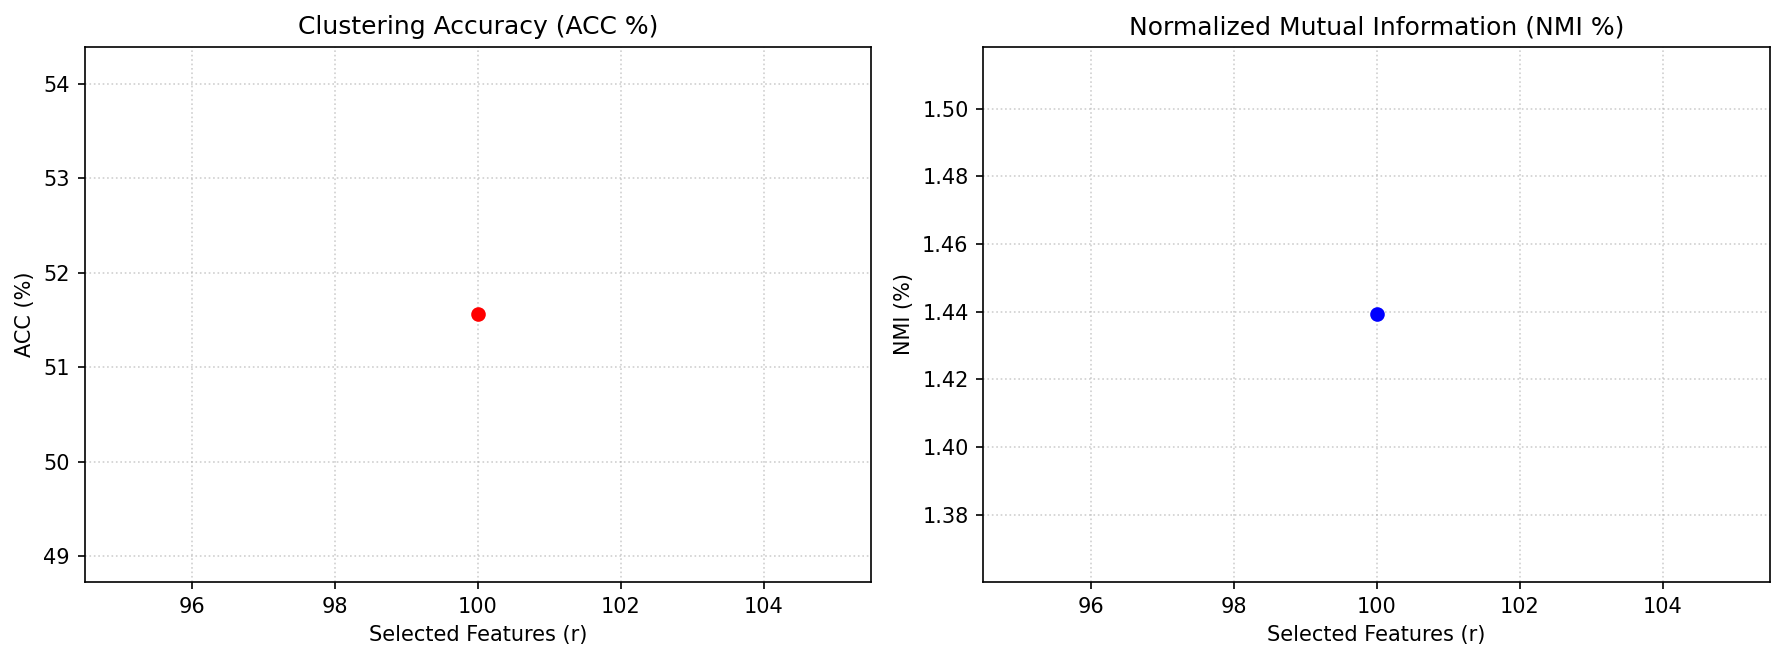

In [119]:
# Cell 7: Module 6 — Experimental Results Plot

import matplotlib.pyplot as plt


fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    dpi=150
)


ax1.plot(
    results_df['Selected Features (r)'],
    results_df['ACC_mean'],
    'r-o',
    linewidth=2,
    label='Experimental ACC',
)

ax1.set_title('Clustering Accuracy (ACC %)')
ax1.set_xlabel('Selected Features (r)')
ax1.set_ylabel('ACC (%)')
ax1.grid(True, linestyle=':', alpha=0.6)


ax2.plot(
    results_df['Selected Features (r)'],
    results_df['NMI_mean'],
    'b-o',
    linewidth=2,
    label='Experimental NMI',
)

ax2.set_title('Normalized Mutual Information (NMI %)')
ax2.set_xlabel('Selected Features (r)')
ax2.set_ylabel('NMI (%)')
ax2.grid(True, linestyle=':', alpha=0.6)


plt.tight_layout()
plt.show()